# Smart Waste Classifier — Minggu 2
**Mata Kuliah:** Machine Learning | **Proyek:** Visual Waste Classifier

Notebook ini mencakup:
1. Mount Google Drive & akses dataset
2. Reorganisasi folder → 2 kelas (Organik / Anorganik)
3. Eksplorasi Data / EDA (distribusi, sample gambar)
4. Verifikasi hasil

---
>

##  STEP 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive berhasil di-mount!')

Mounted at /content/drive
Google Drive berhasil di-mount!


In [2]:
import os

# SESUAIKAN path ini dengan lokasi folder dataset di Google Drive kamu
# Contoh: kalau upload ke folder 'ML' di root Drive
DATASET_PATH = '/content/drive/MyDrive/ML/standardized_256'

# Cek apakah path benar
if os.path.exists(DATASET_PATH):
    print(f'   Dataset ditemukan di: {DATASET_PATH}')
    print(f'   Folder yang ada: {os.listdir(DATASET_PATH)}')
else:
    print(f'  Path tidak ditemukan: {DATASET_PATH}')
    print('   Cek nama folder di Google Drive kamu!')

   Dataset ditemukan di: /content/drive/MyDrive/ML/standardized_256
   Folder yang ada: ['trash', 'paper', 'metal', 'biological', 'battery', 'plastic', 'clothes', 'shoes', 'glass', 'cardboard']


## STEP 2 — Cek Distribusi Dataset Asli (10 Kelas)

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Hitung jumlah gambar per kelas
classes = sorted(os.listdir(DATASET_PATH))
counts = {}
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        n = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        counts[cls] = n

total = sum(counts.values())
print(f'{'='*45}')
print(f'  DISTRIBUSI DATASET ASLI (10 KELAS)')
print(f'{'='*45}')
for cls, n in sorted(counts.items(), key=lambda x: -x[1]):
    bar = '█' * (n // 50)
    print(f'  {cls:<15} {n:>5} gambar  {bar}')
print(f'{'='*45}')
print(f'  TOTAL             {total:>5} gambar')
print(f'  Rata-rata/kelas   {total//len(counts):>5} gambar')
print(f'  Kelas terbanyak : {max(counts, key=counts.get)} ({max(counts.values())})')
print(f'  Kelas tersedikit: {min(counts, key=counts.get)} ({min(counts.values())})')
print(f'  Imbalance ratio : {max(counts.values())/min(counts.values()):.1f}x')

  DISTRIBUSI DATASET ASLI (10 KELAS)
  clothes          1892 gambar  █████████████████████████████████████
  glass            1736 gambar  ██████████████████████████████████
  plastic          1597 gambar  ███████████████████████████████
  shoes            1449 gambar  ████████████████████████████
  cardboard        1411 gambar  ████████████████████████████
  paper            1336 gambar  ██████████████████████████
  metal             930 gambar  ██████████████████
  battery           772 gambar  ███████████████
  biological        699 gambar  █████████████
  trash             453 gambar  █████████
  TOTAL             12275 gambar
  Rata-rata/kelas    1227 gambar
  Kelas terbanyak : clothes (1892)
  Kelas tersedikit: trash (453)
  Imbalance ratio : 4.2x


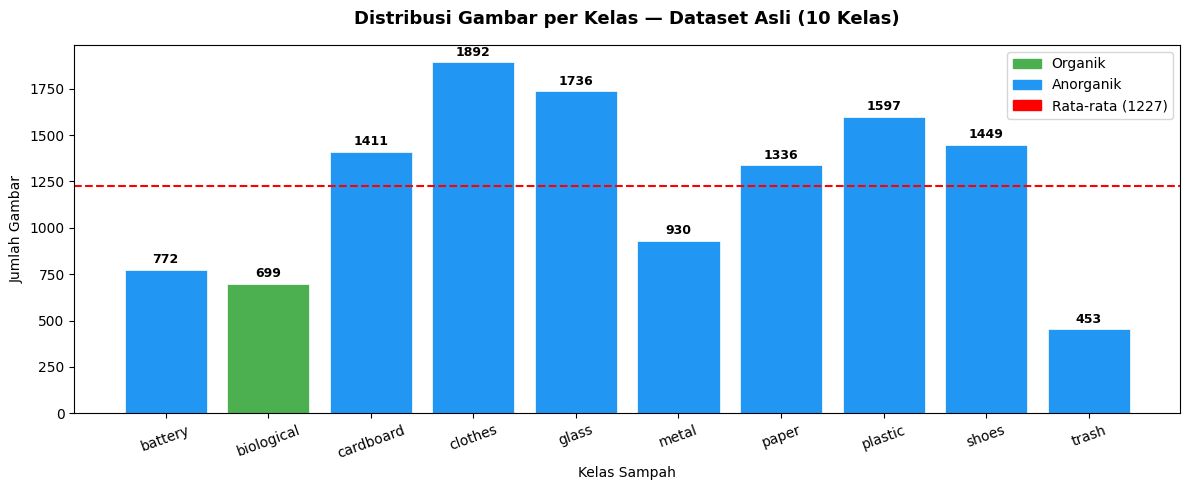

Plot tersimpan: distribusi_kelas_asli.png


In [4]:
# Plot distribusi kelas asli
fig, ax = plt.subplots(figsize=(12, 5))

# Warna: biological = hijau (organik), sisanya = biru
colors = ['#4CAF50' if cls == 'biological' else '#2196F3' for cls in counts.keys()]

bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=total//len(counts), color='red', linestyle='--', linewidth=1.5, label=f'Rata-rata ({total//len(counts)})')

for bar, (cls, n) in zip(bars, counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(n), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Distribusi Gambar per Kelas — Dataset Asli (10 Kelas)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Kelas Sampah')
ax.set_ylabel('Jumlah Gambar')
ax.tick_params(axis='x', rotation=20)

patch_org   = mpatches.Patch(color='#4CAF50', label='Organik')
patch_anorg = mpatches.Patch(color='#2196F3', label='Anorganik')
patch_avg   = mpatches.Patch(color='red',     label=f'Rata-rata ({total//len(counts)})')
ax.legend(handles=[patch_org, patch_anorg, patch_avg], loc='upper right')

plt.tight_layout()
plt.savefig('/content/distribusi_kelas_asli.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan: distribusi_kelas_asli.png')

## STEP 3 — Reorganisasi → 2 Kelas (Organik / Anorganik)

Pemetaan kelas:
| Kelas Asli | → | Kelas Baru |
|---|---|---|
| biological | → | **organik** |
| battery, cardboard, clothes, glass, metal, paper, plastic, shoes, trash | → | **anorganik** |

In [ ]:
import shutil

# Path output dataset 2 kelas
OUTPUT_PATH = '/content/drive/MyDrive/ML/waste_2class'

# Pemetaan kelas
ORGANIK    = ['biological']
ANORGANIK  = ['battery', 'cardboard', 'clothes', 'glass',
               'metal', 'paper', 'plastic', 'shoes', 'trash']

# Buat folder output
for label in ['organik', 'anorganik']:
    os.makedirs(os.path.join(OUTPUT_PATH, label), exist_ok=True)

print('Mulai reorganisasi dataset...')
print(f'Output: {OUTPUT_PATH}')
print()

total_copied = {'organik': 0, 'anorganik': 0}

for cls in os.listdir(DATASET_PATH):
    src_dir = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(src_dir):
        continue

    # Tentukan label baru
    if cls in ORGANIK:
        label = 'organik'
    elif cls in ANORGANIK:
        label = 'anorganik'
    else:
        print(f'Kelas tidak dikenali: {cls}, dilewati')
        continue

    dst_dir = os.path.join(OUTPUT_PATH, label)
    files = [f for f in os.listdir(src_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]

    for fname in files:
        # Tambahkan prefix nama kelas agar tidak konflik nama file
        new_fname = f'{cls}_{fname}'
        shutil.copy2(os.path.join(src_dir, fname), os.path.join(dst_dir, new_fname))

    total_copied[label] += len(files)
    print(f'   {cls:<15} ({len(files)} file) → {label}')

print()
print('='*45)
print('HASIL REORGANISASI:')
print(f'  organik   : {total_copied["organik"]:>5} gambar')
print(f'  anorganik : {total_copied["anorganik"]:>5} gambar')
print(f'  TOTAL     : {sum(total_copied.values()):>5} gambar')
print('='*45)
print(f'Dataset 2 kelas tersimpan di: {OUTPUT_PATH}')

Mulai reorganisasi dataset...
Output: /content/drive/MyDrive/ML/waste_2class

   trash           (453 file) → anorganik
   paper           (1336 file) → anorganik
   metal           (930 file) → anorganik
   biological      (699 file) → organik
   battery         (772 file) → anorganik
   plastic         (1597 file) → anorganik
   clothes         (1892 file) → anorganik
   shoes           (1449 file) → anorganik


##  STEP 4 — EDA Dataset 2 Kelas

In [ ]:
# Distribusi 2 kelas + pie chart
counts_2class = {}
for label in ['organik', 'anorganik']:
    p = os.path.join(OUTPUT_PATH, label)
    counts_2class[label] = len(os.listdir(p))

total_2 = sum(counts_2class.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors2 = ['#4CAF50', '#2196F3']
bars = axes[0].bar(counts_2class.keys(), counts_2class.values(), color=colors2,
                   edgecolor='white', width=0.5)
for bar, (lbl, n) in zip(bars, counts_2class.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{n}\n({n/total_2*100:.1f}%)', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Distribusi Dataset 2 Kelas', fontweight='bold')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].set_ylim(0, max(counts_2class.values()) * 1.2)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts_2class.values(),
    labels=[f'{k}\n({v} gambar)' for k, v in counts_2class.items()],
    colors=colors2, autopct='%1.1f%%',
    startangle=90, pctdistance=0.7,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi Kelas', fontweight='bold')

plt.suptitle('Analisis Dataset Setelah Reorganisasi → 2 Kelas', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/distribusi_2kelas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'   Dataset TIDAK seimbang (imbalanced)!')
print(f'   Organik   : {counts_2class["organik"]:>5} ({counts_2class["organik"]/total_2*100:.1f}%)')
print(f'   Anorganik : {counts_2class["anorganik"]:>5} ({counts_2class["anorganik"]/total_2*100:.1f}%)')
print(f'   Rasio     : 1 : {counts_2class["anorganik"]/counts_2class["organik"]:.1f}')
print()
print(' Solusi: Data augmentation pada kelas organik + class_weight saat training')

In [ ]:
# Tampilkan sample gambar dari setiap kelas
from PIL import Image
import random

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Sample Gambar — Dataset 2 Kelas', fontsize=13, fontweight='bold')

for row_idx, label in enumerate(['organik', 'anorganik']):
    folder = os.path.join(OUTPUT_PATH, label)
    files  = random.sample(os.listdir(folder), 8)

    for col_idx, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname))
        axes[row_idx][col_idx].imshow(img)
        axes[row_idx][col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx][col_idx].set_ylabel(label.upper(), fontsize=11,
                                              fontweight='bold', rotation=90,
                                              labelpad=5)
            axes[row_idx][col_idx].yaxis.set_label_position('left')
            axes[row_idx][col_idx].set_yticks([])

plt.tight_layout()
plt.savefig('/content/sample_gambar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample gambar tersimpan: sample_gambar.png')

In [ ]:
# Cek ukuran gambar (resolusi)
from PIL import Image

print('Mengecek ukuran gambar (sample 20 gambar per kelas)...')
print()

for label in ['organik', 'anorganik']:
    folder = os.path.join(OUTPUT_PATH, label)
    files  = random.sample(os.listdir(folder), min(20, len(os.listdir(folder))))
    sizes  = []
    for fname in files:
        img = Image.open(os.path.join(folder, fname))
        sizes.append(img.size)

    widths  = [s[0] for s in sizes]
    heights = [s[1] for s in sizes]
    print(f'  [{label.upper()}]')
    print(f'    Width  — min:{min(widths)}, max:{max(widths)}, avg:{int(np.mean(widths))}px')
    print(f'    Height — min:{min(heights)}, max:{max(heights)}, avg:{int(np.mean(heights))}px')
    unique_sizes = set(sizes)
    if len(unique_sizes) == 1:
        print(f'     Semua gambar ukuran seragam: {unique_sizes.pop()}')
    else:
        print(f'      Ukuran bervariasi ({len(unique_sizes)} ukuran berbeda) → perlu resize')
    print()

##
STEP 5 — Ringkasan EDA untuk Laporan

In [ ]:
print('=' * 55)
print('  RINGKASAN EDA — MINGGU 2')
print('  Smart Waste Classifier · Visual Waste Classifier')
print('=' * 55)
print()
print('   DATASET ASLI (standardized_256):')
for cls, n in sorted(counts.items(), key=lambda x: -x[1]):
    kategori = '🟢 organik' if cls == 'biological' else '🔵 anorganik'
    print(f'   {cls:<15} {n:>5} gambar  [{kategori}]')
print(f'   {"TOTAL":<15} {total:>5} gambar')
print()
print('   DATASET REORGANISASI (2 kelas):')
for lbl, n in counts_2class.items():
    print(f'   {lbl:<15} {n:>5} gambar  ({n/total_2*100:.1f}%)')
print(f'   {"TOTAL":<15} {total_2:>5} gambar')
print()
print('     TEMUAN PENTING:')
print(f'   • Dataset imbalanced — rasio 1:{counts_2class["anorganik"]/counts_2class["organik"]:.1f} (organik:anorganik)')
print(f'   • Format gambar: JPG/JPEG/PNG')
print(f'   • Resolusi (standardized_256): 256 × 256 px')
print()
print('   RENCANA MINGGU 3 (Pre-processing & Desain Model):')
print('   • Data augmentation (flip, rotate, zoom) pada kelas organik')
print('   • Normalisasi pixel: nilai 0–255 → 0.0–1.0')
print('   • Split: 80% train / 10% val / 10% test')
print('   • Model: MobileNetV2 + Transfer Learning dari ImageNet')
print('   • Class weights untuk mengatasi imbalance')
print('=' * 55)

In [ ]:
# Download semua output sekaligus
from google.colab import files
for f in ['distribusi_kelas_asli.png', 'distribusi_2kelas.png', 'sample_gambar.png']:
    files.download(f'/content/{f}')
    print(f'Downloaded: {f}')